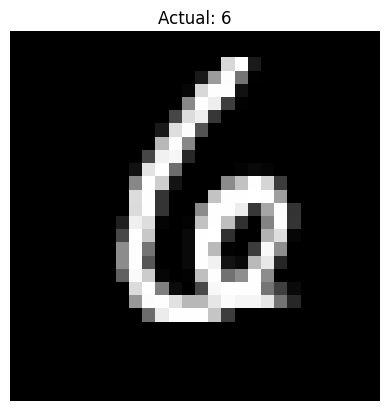

Actual: 6
Predicted: 6
Confidence: 1.0


In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load model
model = tf.keras.models.load_model("../model/digit_model.keras")

# Load MNIST
(_, _), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
X_test = X_test.astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

index = 123

plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
plt.title(f"Actual: {y_test[index]}")
plt.axis("off")
plt.show()

prediction = model.predict(X_test[index:index+1], verbose=0)

print("Actual:", y_test[index])
print("Predicted:", np.argmax(prediction))
print("Confidence:", np.max(prediction))

In [19]:
import os

os.makedirs("../model", exist_ok=True)

model.save("../model/digit_model.keras")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [1]:
import matplotlib.pyplot as plt
import numpy as np

index = 15   # Try any number from 0 to 9999

plt.imshow(X_test[index].reshape(28,28), cmap="gray")
plt.title(f"Actual: {y_test[index]}")
plt.axis("off")
plt.show()

prediction = model.predict(X_test[index].reshape(1,28,28,1))

print("Predicted:", np.argmax(prediction))

NameError: name 'X_test' is not defined

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess test images
X_test = X_test.astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

# Load your trained model
model = tf.keras.models.load_model("../model/digit_model.keras")

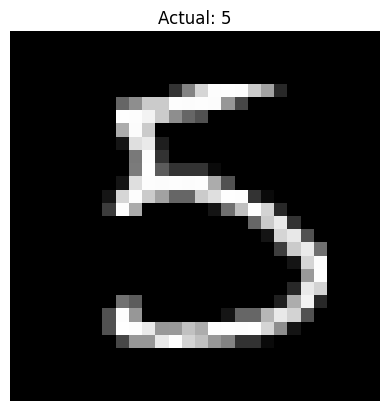

Actual: 5
Predicted: 5
Confidence: 100.0 %


In [3]:
index = 15  # Try different values like 0, 10, 100, 500

plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
plt.title(f"Actual: {y_test[index]}")
plt.axis("off")
plt.show()

prediction = model.predict(X_test[index].reshape(1, 28, 28, 1), verbose=0)

print("Actual:", y_test[index])
print("Predicted:", np.argmax(prediction))
print("Confidence:", np.max(prediction) * 100, "%")

In [18]:
import os

print(os.getcwd())

c:\Users\Navya\OneDrive\Attachments\Desktop\Handwritten-Digit-Recognition\notebooks


In [17]:
import os

os.makedirs("model", exist_ok=True)

In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9924 - loss: 0.0294
Test Accuracy: 0.9924
Test Loss: 0.0294


In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9260 - loss: 0.2424 - val_accuracy: 0.9826 - val_loss: 0.0594
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 20ms/step - accuracy: 0.9739 - loss: 0.0866 - val_accuracy: 0.9874 - val_loss: 0.0400
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9812 - loss: 0.0621 - val_accuracy: 0.9866 - val_loss: 0.0433
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9849 - loss: 0.0501 - val_accuracy: 0.9898 - val_loss: 0.0386
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9871 - loss: 0.0413 - val_accuracy: 0.9906 - val_loss: 0.0380
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9886 - loss: 0.0361 - val_accuracy: 0.9918 - val_loss: 0.0342
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.9901 - loss: 0.0308 - val_accuracy: 0.9918 - val_loss: 0.0354
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9908 -

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten the feature maps
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout helps prevent overfitting
model.add(Dropout(0.5))

# Output Layer (10 digits: 0–9)
model.add(Dense(10, activation='softmax'))

c:\Users\Navya\OneDrive\Attachments\Desktop\Handwritten-Digit-Recognition\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

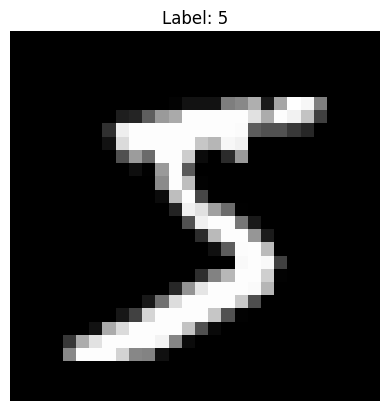

In [8]:
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [7]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


In [6]:
# Convert pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum value:", X_train.min())
print("Maximum value:", X_train.max())

Minimum value: 0.0
Maximum value: 1.0


In [5]:
print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


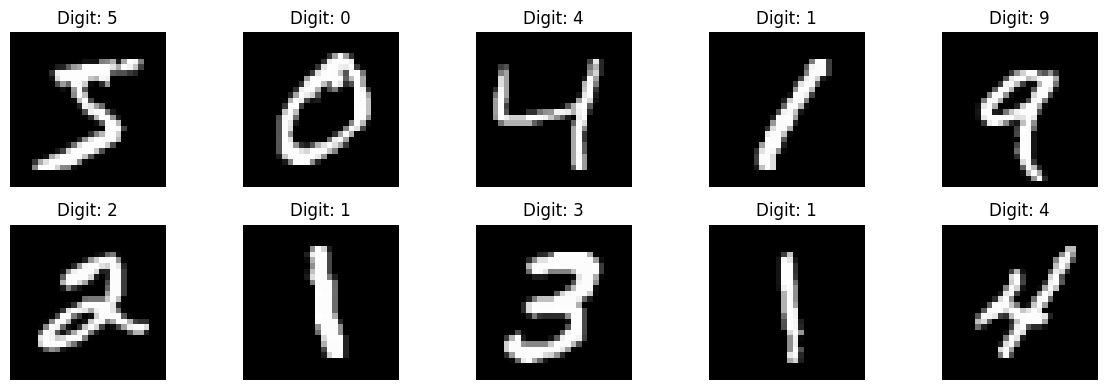

In [4]:
plt.figure(figsize=(12,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

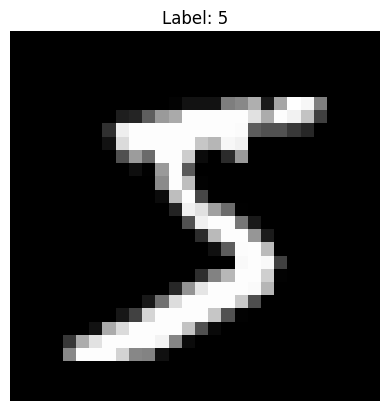

In [3]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0
